In [ ]:
import warnings
import stpsf

import astropy.units as u
import pathlib
import FunctionLib as FL
import inspect
from tqdm import tqdm
import astropy
import wave
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from collections import defaultdict
import re
import scipy
from astropy.io import fits as asfits

mpl.rcParams['font.family'] = 'serif'

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
warnings.filterwarnings("ignore")

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(os.path.expanduser(
    './DJAV4.2Catalog.pkl'))
print(DJAv4Catalog.sample_num())

DJAv4Catalog.to_dataframe()

In [ ]:
for survey_id_subid, catalog in DJAv4Catalog.catalog_iterator():
    if survey_id_subid=='stark-rxcj2248-v4_2478_3':
        print(catalog)

        for disperser_filter, filepath in catalog['grating_filepaths'].items():

            grating_spectrum=FL.Load_Spectrum_From_Fits(filepath, catalog['determined_redshift'])
            grating_spectrum.set_boundarys(4800*u.AA,6600*u.AA)
            grating_spectrum.show()


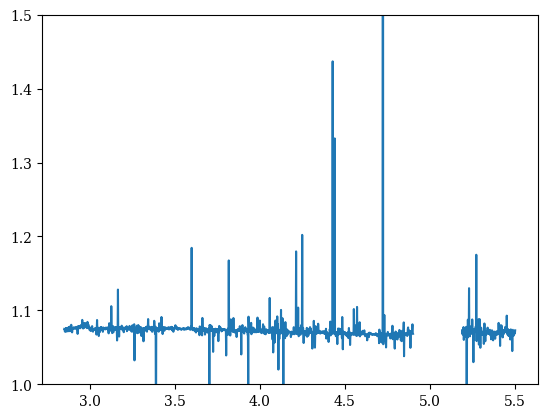

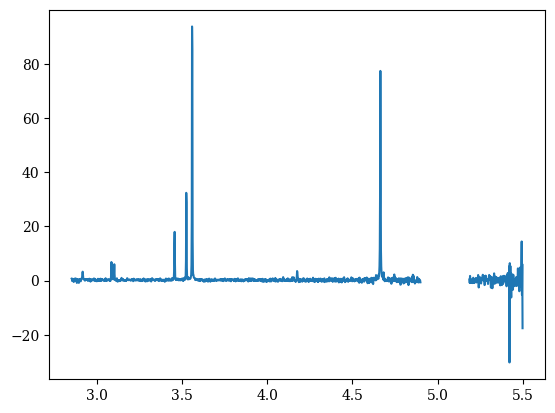

In [16]:
with asfits.open(filepath) as grating_spectrum_fits:
    plt.plot(grating_spectrum_fits[1].data['WAVE'][100:], grating_spectrum_fits[1].data['PATH_CORR'][100:])
    plt.ylim(1,1.5)
    plt.show()
    plt.plot(grating_spectrum_fits[1].data['WAVE'][100:], grating_spectrum_fits[1].data['flux'][100:])

In [ ]:
alpharestFrameWavelength=6563.0*astropy.units.AA

grating_spectrum.set_boundarys(alpharestFrameWavelength-75.0*astropy.units.AA, alpharestFrameWavelength+75.0*astropy.units.AA)


alphaspectralLineFitter=FL.SpectralLineFitter(grating_spectrum,alpharestFrameWavelength)

alpha_fit_result=alphaspectralLineFitter.fit_single_gaussian_with_offset()

alpha_fitting_uncertainty_value, alpha_flux_calculated=FL.fitting_uncertainty(alpha_fit_result)

SNR=alpha_flux_calculated/alpha_fitting_uncertainty_value


#beta

grating_spectrum.reset()
betarestFrameWavelength=4861.0*astropy.units.AA
grating_spectrum.set_boundarys(betarestFrameWavelength-75.0*astropy.units.AA, betarestFrameWavelength+75.0*astropy.units.AA)

betaspectralLineFitter=FL.SpectralLineFitter(grating_spectrum,betarestFrameWavelength)

beta_fit_result=betaspectralLineFitter.fit_single_gaussian_with_offset()

beta_fitting_uncertainty_value, beta_flux_calculated=FL.fitting_uncertainty(beta_fit_result)

beta_SNR=beta_flux_calculated/beta_fitting_uncertainty_value



In [ ]:
SNR

In [ ]:
beta_SNR

In [ ]:
alpha_flux_calculated/beta_flux_calculated

In [ ]:
def load_pathloss_correction(file_path, redshift):

    halpha_rest = 0.6563 * u.micron
    halpha_obs = halpha_rest * (1 + redshift)
    hbeta_rest = 0.4861 * u.micron
    hbeta_obs = hbeta_rest * (1 + redshift)

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    if not file_path.endswith('.fits'):
        raise ValueError("File must be a .fits file")

    with asfits.open(file_path) as hdul:
        data = hdul[1].data
        wavelength = data['wave']*u.micron

        mock_alpha=(((halpha_obs-0.1*u.micron)< wavelength)&(wavelength < (halpha_obs+0.1*u.micron)))
        mock_beta=(((hbeta_obs-0.1*u.micron)< wavelength)&(wavelength < (hbeta_obs+0.1*u.micron)))

        halpha_pl_corr =np.nanmedian(data['path_corr'][mock_alpha])
        hbeta_pl_corr =np.nanmedian(data['path_corr'][mock_beta])

        return halpha_pl_corr, hbeta_pl_corr


In [ ]:
halpha_pl_corr_list = []
hbeta_pl_corr_list = []
halpha_sl_corr_list = []
hbeta_sl_corr_list = []

for survey_id_subid, catalog in DJAv4Catalog.catalog_iterator():

    if not catalog.get('sample_flag', False):
        continue

    if catalog['determined_redshift']<4:
        continue

    for disperser_filter, grating_filepath in catalog.get('grating_within_coverage', {}).items():
        filter_name = disperser_filter.split('-')[1]

        redshift = catalog['determined_redshift']
        halpha_pl_corr, hbeta_pl_corr = load_pathloss_correction(
            grating_filepath, redshift)

        halpha_pl_corr_list.append(halpha_pl_corr)
        hbeta_pl_corr_list.append(hbeta_pl_corr)
        halpha_sl_corr_list.append(1/
            catalog['grating_slitloss_correction'][f'halpha_psf_fraction_{filter_name}']
        )
        hbeta_sl_corr_list.append(1/
            catalog['grating_slitloss_correction'][f'hbeta_psf_fraction_{filter_name}']
        )

halpha_sl_corr_list = np.array(halpha_sl_corr_list)
hbeta_sl_corr_list = np.array(hbeta_sl_corr_list)
halpha_pl_corr_list = np.array(halpha_pl_corr_list)
hbeta_pl_corr_list = np.array(hbeta_pl_corr_list)

In [ ]:
fig, ax=plt.subplots(1, 2, figsize=(20,10))
ax[0].scatter(halpha_sl_corr_list, hbeta_sl_corr_list, s=10, alpha=0.7, label='Slitloss Correction', color='C0')
ax[0].plot([1,2.6], [1,2.6], color='black', linestyle='--', linewidth=2)
ax[0].set_xlabel('Hα Slitloss Correction Factor', fontsize=16)
ax[0].set_ylabel('Hβ Slitloss Correction Factor', fontsize=16)
ax[0].set_xlim(1,2.6)
ax[0].set_ylim(1,2.6)
ax[0].minorticks_on()
ax[0].spines['bottom'].set_linewidth(2)
ax[0].spines['top'].set_linewidth(2)
ax[0].spines['left'].set_linewidth(2)
ax[0].spines['right'].set_linewidth(2)
ax[0].spines['bottom'].set_color('black')
ax[0].spines['top'].set_color('black')
ax[0].spines['left'].set_color('black')
ax[0].spines['right'].set_color('black')
ax[0].yaxis.set_ticks_position('both')
ax[0].xaxis.set_ticks_position('both')
ax[0].xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=14)
ax[0].yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=14)
ax[0].xaxis.set_tick_params(length=6, which='major')
ax[0].xaxis.set_tick_params(length=3, which='minor')
ax[0].yaxis.set_tick_params(length=6, which='major')
ax[0].yaxis.set_tick_params(length=3, which='minor')
ax[0].grid(visible=True, which='major', color='gray', linestyle='--', linewidth=1)
ax[0].grid(visible=True, which='minor', color='lightgray', linestyle='--', linewidth=0.5)
ax[0].set_title('Slitloss Correction Factors', fontsize=18)

ax[1].scatter(halpha_pl_corr_list, hbeta_pl_corr_list, s=10, alpha=0.7, label='Pathloss Correction', color='C1')
ax[1].plot([1,2.6], [1,2.6], color='black', linestyle='--', linewidth=2)
ax[1].set_xlabel('Hα Pathloss Correction Factor', fontsize=16)
ax[1].set_ylabel('Hβ Pathloss Correction Factor', fontsize=16)
ax[1].set_xlim(1,2.6)
ax[1].set_ylim(1,2.6)
ax[1].minorticks_on()
ax[1].spines['bottom'].set_linewidth(2)
ax[1].spines['top'].set_linewidth(2)
ax[1].spines['left'].set_linewidth(2)
ax[1].spines['right'].set_linewidth(2)
ax[1].spines['bottom'].set_color('black')
ax[1].spines['top'].set_color('black')
ax[1].spines['left'].set_color('black')
ax[1].spines['right'].set_color('black')
ax[1].yaxis.set_ticks_position('both')
ax[1].xaxis.set_ticks_position('both')
ax[1].xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=14)
ax[1].yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=14)
ax[1].xaxis.set_tick_params(length=6, which='major')
ax[1].xaxis.set_tick_params(length=3, which='minor')
ax[1].yaxis.set_tick_params(length=6, which='major')
ax[1].yaxis.set_tick_params(length=3, which='minor')
ax[1].grid(visible=True, which='major', color='gray', linestyle='--', linewidth=1)
ax[1].grid(visible=True, which='minor', color='lightgray', linestyle='--', linewidth=0.5)
ax[1].set_title('Pathloss Correction Factors', fontsize=18)

plt.tight_layout()
plt.savefig('halpha_hbeta_slitloss_pathloss_correction_comparison.pdf')
plt.close()

In [ ]:
fig, ax=plt.subplots(1,1, figsize=(14,10))
ax.hist(halpha_sl_corr_list/hbeta_sl_corr_list, bins=80, range=[0.95,1.2],alpha=0.6, label='Slitloss Correction')
ax.hist(halpha_pl_corr_list/hbeta_pl_corr_list, bins=32, range=[0.95,1.05], alpha=0.6, label='Pathloss Correction')
ax.spines['bottom'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['right'].set_linewidth(2)
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.xaxis.set_tick_params(width=2, direction='in', which='both', labelsize=14)
ax.yaxis.set_tick_params(width=2, direction='in', which='both', labelsize=14)
ax.xaxis.set_tick_params(length=6, which='major')
ax.xaxis.set_tick_params(length=3, which='minor')
ax.yaxis.set_tick_params(length=6, which='major')
ax.yaxis.set_tick_params(length=3, which='minor')
ax.grid(visible=True, which='major', color='gray', linestyle='--', linewidth=1)
ax.grid(visible=True, which='minor', color='lightgray', linestyle='--', linewidth=0.5)
ax.legend(fontsize=14, loc='best')
ax.set_xlabel('Hα/Hβ Correction Factor Ratio', fontsize=16)
ax.set_ylabel('Number of Galaxies', fontsize=16)
ax.set_title('Distribution of Hα to Hβ Correction Factor Ratios', fontsize=18)
plt.savefig('hist2.pdf')
plt.show()

In [ ]:
for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator(1000):
    if not catalog.get('sample_flag', False):
        continue

    if catalog['determined_redshift'] < 4.5:
        continue
    slitloss=catalog['grating_slitloss_correction']
    for disperser_filter, grating_filename in catalog.get('grating_within_coverage', {}).items():
        hdul=asfits.open(grating_filename)

        halpha_corr=1/slitloss[f'halpha_psf_fraction_{disperser_filter.split("-")[1]}']
        hbeta_corr=1/slitloss[f'hbeta_psf_fraction_{disperser_filter.split("-")[1]}']


        mock=(hdul[1].data['wave']<0.4863*(1+catalog['determined_redshift'])+0.2)&(hdul[1].data['wave']>0.4863*(1+catalog['determined_redshift'])-0.2)
        correct_value=np.nanmedian(hdul[1].data['path_corr'][mock])

        #normalized_pathloss_factor=(np.nanpercentile(hdul[1].data['path_corr'],20))
        normalized_pathloss_factor=1


        plt.figure(figsize=(24,8))
        plt.plot(hdul[1].data['wave'], hdul[1].data['path_corr']/(normalized_pathloss_factor), label='Pathloss Correction')
        plt.axhline(1, color='black', linestyle='--')
        plt.axvline(0.4863*(1+catalog['determined_redshift']), color='red', linestyle='--')
        plt.axvline(0.6563*(1+catalog['determined_redshift']), color='red', linestyle='--')
        plt.scatter(0.4863*(1+catalog['determined_redshift']), correct_value/normalized_pathloss_factor, color='red',s=100)
        plt.scatter(0.6563*(1+catalog['determined_redshift']), halpha_corr/hbeta_corr*correct_value/normalized_pathloss_factor, color='red',s=100)
        plt.title(f'SurveyID-SubID: {surveyid_subid}, Disperser-Filter: {disperser_filter}')
        plt.xlabel('Wavelength (micron)')
        plt.ylabel('Pathloss Correction (Normalized)')
        # plt.ylim(np.nanpercentile(hdul[1].data['path_corr']/(np.nanmedian(hdul[1].data['path_corr'])), 10), np.nanpercentile(hdul[1].data['path_corr']/(np.nanmedian(hdul[1].data['path_corr'])), 90))
        plt.ylim(correct_value/normalized_pathloss_factor-0.02,halpha_corr/hbeta_corr*correct_value/normalized_pathloss_factor+0.02)
        plt.show()
        plt.close()

    # print(catalog['grating_slitloss_correction'])
    # print(catalog['determined_redshift'])

    # print('-------------------')
    # print('-------------------')

    # break